# A3 practical — A noisy microscope
## Blood cell classification with a CNN and RGB restoration with a GRU
**Names:** ...  **Date:** ...

Duration: 3 hours.
Complete the TODO code and written answers in English.
Use BloodMNIST: colour microscope images of eight cell categories.
The CNN classifies cells; a separate unidirectional GRU restores artificially noisy images.
Read `ASSIGNMENT_EN_CNN_Improved.md`. 
Keep the supplied partitions and use validation for model selection.
Schedule: data 15 min · CNN 65 min · noise 15 min · GRU 50 min · evaluation 25 min · conclusion 10 min.
Note that this is an educational image-processing experiment.


## 0. Setup — supplied
Install requirements before class. Run the notebook from this folder. The provided RGB subset allows offline execution.


In [1]:
from pathlib import Path
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Dataset loading uses the supplied preparation script.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # use mps for mac
print('Device:', device)
print('BloodMNIST improved models: CNN 32/64 filters with BatchNorm and dropout; unidirectional GRU hidden size 128.')
CNN_EPOCHS = 30
GRU_EPOCHS = 25
BATCH_SIZE = 128
SIGMA = 0.20

Device: cpu
BloodMNIST improved models: CNN 32/64 filters with BatchNorm and dropout; unidirectional GRU hidden size 128.


In [3]:
cache = Path('data/blood_mnist_subset.npz') #specify the path to your dataset
if not cache.exists():
    from prepare_data import main as prepare_dataset
    prepare_dataset()
with np.load(cache, allow_pickle=False) as data:
    image_sets = [data[key].copy() for key in ['train_images', 'val_images', 'test_images']]
    label_sets = [data[key].copy() for key in ['train_labels', 'val_labels', 'test_labels']]
images_np = np.concatenate(image_sets)
labels_np = np.concatenate(label_sets)
X = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
y = torch.tensor(labels_np, dtype=torch.long)
N_CLASSES = 8
CLASS_NAMES = ['Basophil', 'Eosinophil', 'Erythroblast', 'Immature granulocytes',
               'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']
assert X.shape == (4640, 3, 28, 28)
assert X.min() >= 0 and X.max() <= 1
cnn_train_ids = np.arange(3200)
cnn_val_ids = np.arange(3200, 3840)
cnn_test_ids = np.arange(3840, 4640)
cnn_train_loader = DataLoader(TensorDataset(X[cnn_train_ids], y[cnn_train_ids]),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
cnn_val_loader = DataLoader(TensorDataset(X[cnn_val_ids], y[cnn_val_ids]), batch_size=BATCH_SIZE)
cnn_test_loader = DataLoader(TensorDataset(X[cnn_test_ids], y[cnn_test_ids]), batch_size=BATCH_SIZE)
# Both tasks use the same held-out images; class labels are never used by the denoiser.
den_train_ids, den_val_ids, den_test_ids = cnn_train_ids, cnn_val_ids, cnn_test_ids
clean_train, clean_val, clean_test = X[den_train_ids], X[den_val_ids], X[den_test_ids]
den_train_loader = DataLoader(TensorDataset(clean_train), batch_size=BATCH_SIZE, shuffle=True)
print('Images:', len(clean_train), len(clean_val), len(clean_test))
print('Class IDs and names:', dict(enumerate(CLASS_NAMES)))

Images: 3200 640 800
Class IDs and names: {0: 'Basophil', 1: 'Eosinophil', 2: 'Erythroblast', 3: 'Immature granulocytes', 4: 'Lymphocyte', 5: 'Monocyte', 6: 'Neutrophil', 7: 'Platelet'}


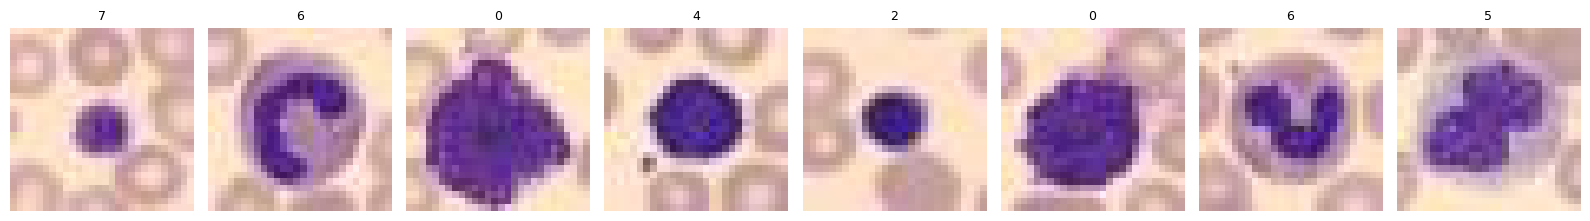

Full tensor: (4640, 3, 28, 28)
Mini-batch: (128, 3, 28, 28)


In [4]:
def show_images(images, titles=None, n=8):
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5), squeeze=False)
    for i, ax in enumerate(axes[0]):
        ax.imshow(images[i].detach().cpu().permute(1, 2, 0))
        ax.axis('off')
        if titles is not None: ax.set_title(str(titles[i]), fontsize=9)
    plt.tight_layout(); plt.show()

show_images(X[cnn_train_ids[:8]], y[cnn_train_ids[:8]].tolist())
print('Full tensor:', tuple(X.shape))
print('Mini-batch:', tuple(next(iter(cnn_train_loader))[0].shape))

### Q1 — Data and generalisation
1. Explain each dimension of the mini-batch.
2. Why must both tasks keep the same images out of training?
3. What do the eight class IDs represent? Give three examples.

**Your answers:** 

**1. Dimensions of the mini-batch:**
The mini-batch tensor has the shape `(B, C, H, W)`:
- **B (Batch size = 128):** The number of images processed simultaneously in one iteration during training/inference.
- **C (Channels = 3):** The RGB color channels (Red, Green, Blue).
- **H (Height = 28):** The vertical dimension of the image in pixels.
- **W (Width = 28):** The horizontal dimension of the image in pixels.

**2. Keeping the same images out of training (Data Leakage & Evaluation):**
Both tasks must share the exact same validation and test splits (`train_ids`, `val_ids`, `test_ids`) to avoid **data leakage**. If an image used to train the GRU denoiser was in the test set of the CNN classifier (or vice versa), the models would be evaluated on data they have already partially seen during training. Keeping identical held-out sets ensures an unbiased evaluation of generalization and allows us to fairly test how the CNN performs on GRU-restored images.

**3. The eight class IDs and 3 examples:**
The eight class IDs represent different cell types and blood components extracted from microscopic blood smear images (from the BloodMNIST dataset). 

Three examples:
- **Basophil (ID 0):** A type of white blood cell involved in immune/allergic responses.
- **Lymphocyte (ID 4):** A white blood cell responsible for adaptive immunity.
- **Platelet (ID 7):** Cell fragments essential for blood clotting and stopping bleeding.

## 1. CNN — shapes and manual parameter count (45 min)
Use two convolution blocks (kernel 3, stride 1, padding 1), each followed by BatchNorm2d, ReLU and MaxPool2d(2). Add a 128-unit hidden linear layer, ReLU, dropout 0.25 and eight output logits. All convolutions and linear layers include biases.

### Research task — two new layers (10 minutes within the CNN section)
Before using these supplied layers, consult the official PyTorch documentation for [BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) and [Dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html).

1. In your own words, what does each layer do? Why might it help a classifier?
2. How does each layer behave in `model.train()` and `model.eval()` modes?
3. What does `p=0.25` mean for Dropout? What happens to the retained activations?
4. Which values are learned by BatchNorm? What are its running statistics? Does Dropout have trainable parameters?
5. Explain why evaluation must call `model.eval()` even inside `torch.no_grad()`.

Include your source links and a short explanation rather than copying the documentation.
**Your research notes:** 
1. BatchNorm2d normalizes the outputs of a convolutional layer across the mini-batch so that they maintain a mean of 0 and a variance of 1. This stabilizes the internal representations, allowing the classifier to train faster, use higher learning rates, and converge to a better local minimum. Dropout randomly zeroes out parts of the input tensor during training. This acts as a regularizer, preventing the classifier from co-adapting and relying too heavily on specific neurons, which significantly reduces overfitting.

2. During train() mode, BatchNorm computes the mean and variance from the current batch to normalize the data, and it updates its internal running statistics. Dropout actively drops elements with probability $p$. In eval() mode, BatchNorm stops computing real-time batch statistics and instead uses its saved historical running statistics to normalize the data deterministically. Dropout becomes an identity function, deactivating completely and passing all activations through unchanged.

3. p=0.25 means that every element has a 25% probability of being zeroed out on each forward pass. To compensate for the loss of that 25% of information, the remaining 75% of the values ​​are multiplied by $1/(1-0.25)$ (i.e., approximately $1.33$). This way, the overall energy of your signal remains exactly the same between the training phase (with gaps) and the testing phase (without gaps).

4. BatchNorm learns two trainable parameters per channel: a scale weight ($\gamma$) and a shift bias ($\beta$). Its running statistics are the historical, exponentially averaged mean and variance of the dataset, which are strictly non-trainable buffers updated passively during training. Dropout has zero trainable parameters.

5.torch.no_grad() purely disables gradient tracking in the autograd engine to save memory and computation time; it does not change the operational mode of the network's layers. model.eval() is explicitly required to signal layers like BatchNorm and Dropout to switch from their stochastic training behaviors to their deterministic inference behaviors.

Complete this table before using the automatic counter:

| Layer | Output shape | Manual trainable parameters |
|---|---|---|
| Input, fixed rescaling to [-1,1] | (B,3,28,28) | 0 |
| Conv2d 3 → 32 | (B,32,28,28) | 896 |
| BatchNorm2d(32), ReLU | (B,32,28,28) | 64 |
| MaxPool2d | (B,32,14,14) | 0 |
| Conv2d 32 → 64 | (B,64,14,14) | 18496 |
| BatchNorm2d(64), ReLU | (B,64,14,14) | 128 |
| MaxPool2d | (B,64,7,7) | 0 |
| Flatten | (B,3136) | 0 |
| Linear → 128, ReLU | (B,128) | 401536 |
| Dropout(0.25) | (B,128) | 0 |
| Linear → 8 logits | (B,8) | 1032 |
| **Total** | — | 422152 |

Convolution: Cout(Cin k²+1). Linear: dout(din+1). Batch normalisation: 2C (scale and shift).
Explain why dropout, ReLU and pooling add no learned parameters.
**Your calculations and explanation:** 

- Conv2d 3 to 32: We create 32 filters. Each filter looks at a 3x3 pixel area across 3 input color channels. This gives 3 x 3 x 3 = 27 weights, plus 1 bias per filter. So, 28 parameters per filter. 32 filters x 28 = 896.

- BatchNorm2d(32): The network learns only 2 parameters per channel to stabilize the signal: a scale multiplier and a shift value. 32 channels x 2 = 64.

- Conv2d 32 to 64: We create 64 filters. Each filter looks at a 3x3 area across the 32 previous channels. This gives 32 x 3 x 3 = 288 weights, plus 1 bias = 289. 64 filters x 289 = 18496.

- BatchNorm2d(64): Same logic as before. 64 channels x 2 parameters = 128.

- Linear 128: The image is flattened from 64 channels of 7x7 pixels into a single line of 3136 values. We connect these to 128 new neurons. For each neuron, there are 3136 connections plus 1 bias (3137). 128 neurons x 3137 = 401536.

- Linear 8: We connect the 128 neurons to our 8 final cell categories. 8 outputs x (128 connections + 1 bias) = 1032.

Zero-parameter layers (Dropout, ReLU, MaxPool2d): These layers do not have any weights to learn.

We have 896 + 64 + 18 496 + 128 + 401 536 + 1 032 = 422 152 parameters.

In [6]:
cnn = SmallCNN().to(device)
assert cnn(torch.zeros(3, 3, 28, 28, device=device)).shape == (3, N_CLASSES)
assert cnn(torch.zeros(1, 3, 28, 28, device=device)).shape == (1, N_CLASSES)

# Run only after writing the manual calculation above.
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print('CNN parameter count:', count_parameters(cnn))

CNN parameter count: 422152


## 2. CNN training and evaluation (20 min)
Complete the gradient-update helper. It will also be reused for denoising.
The supplied loop evaluates validation loss and keeps the best checkpoint.

### Q2
Why should `CrossEntropyLoss` receive logits rather than softmax probabilities?
What is uniform-random accuracy for 8 classes? What do `train()`, `eval()` and `no_grad()` do?

**Your answers:**
PyTorch's CrossEntropyLoss internally combines LogSoftmax and NLLLoss (Negative Log-Likelihood Loss) into a single, highly optimized operation. If we pass already-softmaxed probabilities, the loss function will incorrectly apply softmax a second time.
If the model guesses uniformly at random among 8 balanced classes, the expected accuracy is 1/8, which equals 0.125 or 12.5%.

train(): Sets the model to training mode. This activates regularization behaviors, such as dropping neurons in Dropout and calculating/updating batch statistics in BatchNorm.

eval(): Sets the model to evaluation/inference mode. This disables Dropout (acting as an identity function) and forces BatchNorm to use its saved historical running statistics instead of the current batch data.

torch.no_grad(): A context manager that completely disables gradient tracking in the autograd engine. This prevents backpropagation calculations, reducing memory consumption and speeding up computations during evaluation.

In [ ]:
def update_batch(model, inputs, targets, optimizer, criterion):
    optimizer.zero_grad()  # T1: reset gradients
    predictions = model(inputs)  # T2
    loss = criterion(predictions, targets)  # T3
    loss.backward()  # T4: backpropagation
    optimizer.step()  # T5: update weights
    return loss.item()

cnn_criterion = nn.CrossEntropyLoss()  # T6
cnn_optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001, weight_decay=0.0001)  # T7: Adam, learning rate 0.001, weight_decay=0.0001

Epoch 1: train=1.3173, val=1.7372
Epoch 2: train=0.6865, val=0.7395
Epoch 3: train=0.5069, val=0.5268
Epoch 4: train=0.4450, val=0.3957
Epoch 5: train=0.3665, val=0.4819
Epoch 6: train=0.3232, val=0.3448
Epoch 7: train=0.2797, val=0.3390
Epoch 8: train=0.2591, val=0.3267
Epoch 9: train=0.2363, val=0.3645
Epoch 10: train=0.2023, val=0.3323
Epoch 11: train=0.1874, val=0.3190
Epoch 12: train=0.1634, val=0.3360
Epoch 13: train=0.1478, val=0.4514
Epoch 14: train=0.1283, val=0.2988
Epoch 15: train=0.1094, val=0.2904
Epoch 16: train=0.0999, val=0.2873
Epoch 17: train=0.0855, val=0.2938
Epoch 18: train=0.0886, val=0.2939
Epoch 19: train=0.0779, val=0.3626
Epoch 20: train=0.0633, val=0.2828
Epoch 21: train=0.0607, val=0.2990
Epoch 22: train=0.0484, val=0.3588
Epoch 23: train=0.0374, val=0.2896
Epoch 24: train=0.0446, val=0.2900
Epoch 25: train=0.0429, val=0.3258
Epoch 26: train=0.0494, val=0.2850
Epoch 27: train=0.0786, val=0.3473
Epoch 28: train=0.0539, val=0.3159
Epoch 29: train=0.0434, val=0

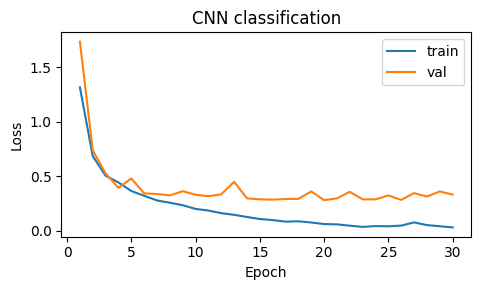

In [8]:
def fit_classifier(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {'train': [], 'val': []}
    best_loss, best_weights = float('inf'), None
    for epoch in range(epochs):
        model.train(); total, count = 0., 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            total += update_batch(model, images, labels, optimizer, criterion)*len(images)
            count += len(images)
        model.eval(); val_total = 0.
        with torch.no_grad():
            for images, labels in val_loader:
                val_total += criterion(model(images.to(device)), labels.to(device)).item()*len(images)
        val_loss = val_total/len(val_loader.dataset)
        history['train'].append(total/count); history['val'].append(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss; best_weights = copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch+1}: train={total/count:.4f}, val={val_loss:.4f}')
    model.load_state_dict(best_weights)
    return history

def plot_history(history, title):
    plt.figure(figsize=(5, 3))
    for key, values in history.items(): plt.plot(range(1, len(values)+1), values, label=key)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

started = time.perf_counter()
cnn_history = fit_classifier(cnn, cnn_train_loader, cnn_val_loader,
                             cnn_optimizer, cnn_criterion, CNN_EPOCHS)
print('CNN seconds:', round(time.perf_counter()-started, 1))
plot_history(cnn_history, 'CNN classification')

In [10]:
@torch.no_grad()
def classification_accuracy(model, loader):
    model.eval(); correct, count = 0, 0
    for images, labels in loader:
        logits = model(images.to(device))
        
        # E1 : Prendre l'index de la classe avec le score le plus élevé
        predicted_ids = logits.argmax(dim=1)  
        
        # E2 : Compter combien de prédictions sont égales aux vraies étiquettes
        correct += (predicted_ids == labels.to(device)).sum().item()       
        
        count += len(labels)
        
    # E3 : accuracy in [0, 1] (le ratio de bonnes réponses)
    return correct / count

cnn_test_accuracy = classification_accuracy(cnn, cnn_test_loader)
print('Test accuracy:', cnn_test_accuracy)

Test accuracy: 0.90125


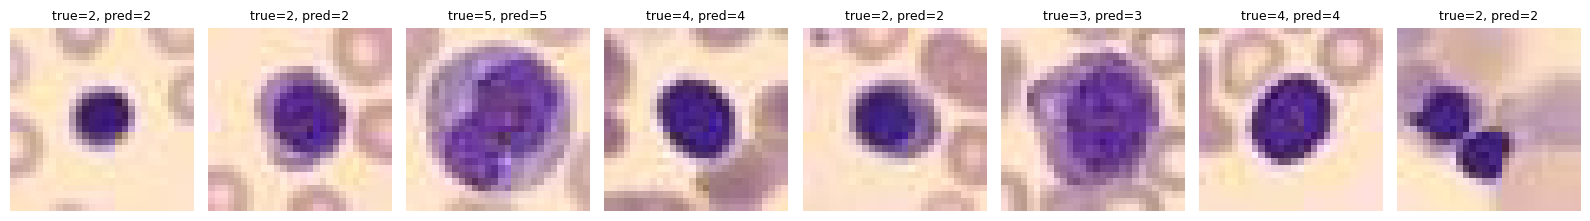

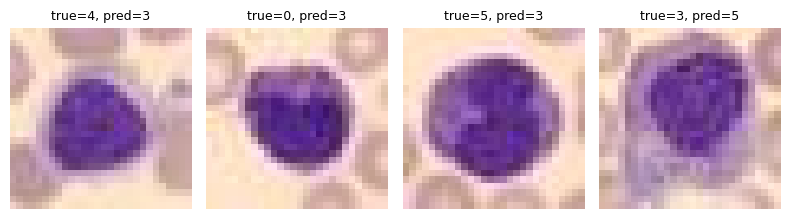

In [11]:
cnn.eval()
with torch.no_grad():
    cnn_predictions = cnn(X[cnn_test_ids].to(device)).argmax(1).cpu()
show_images(X[cnn_test_ids[:8]],
            [f'true={t}, pred={p}' for t,p in zip(y[cnn_test_ids[:8]], cnn_predictions[:8])])
wrong = torch.where(cnn_predictions != y[cnn_test_ids])[0]
if len(wrong):
    chosen = wrong[:4]
    show_images(X[cnn_test_ids[chosen.numpy()]],
                [f'true={t}, pred={p}' for t,p in zip(y[cnn_test_ids[chosen.numpy()]], cnn_predictions[chosen])], n=4)

### Confusion matrix — complete and interpret
Use all 800 test images and the eight labels. Rows represent true categories; columns represent predicted categories.
Complete the code to compute an 8×8 matrix and display cell names on both axes.
Check that its entries sum to the test-set size. Recover accuracy from its diagonal.
Identify the two largest off-diagonal entries and discuss possible visual similarities. What does row normalisation show?
**Your answers:** ...


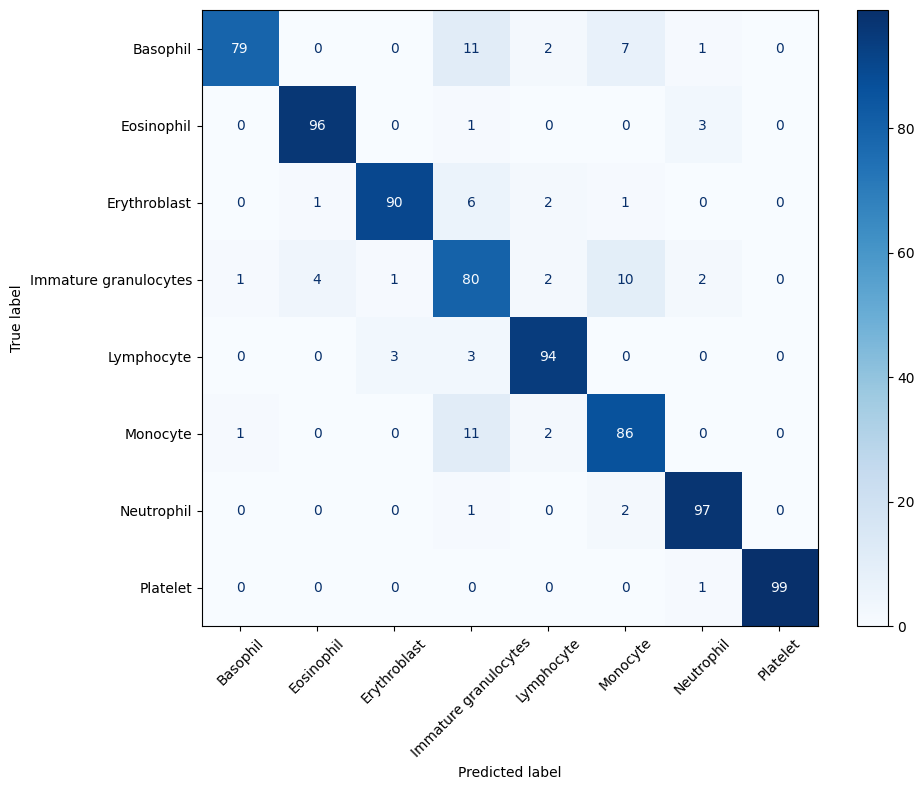

Accuracy from confusion matrix: 0.90125


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TODO CM1: true labels, predicted labels, all eight classes
cm = confusion_matrix(y[cnn_test_ids], cnn_predictions, labels=range(8)) 

assert cm.shape == (8, 8) and cm.sum() == len(cnn_test_ids)
fig, ax = plt.subplots(figsize=(10, 8))

# TODO CM2: display the matrix, class names and readable rotated labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')

plt.tight_layout(); plt.show()

# TODO CM3: diagonal / total
matrix_accuracy = cm.diagonal().sum() / cm.sum() 
print('Accuracy from confusion matrix:', matrix_accuracy)

### Q3 — CNN results
Report test accuracy, compare it with random guessing and comment on the loss curves.
Explain an error, or state that none occurred in the displayed sample.

**Your analysis:** ...

## 3. Add noise and create sequences (15 min)
Complete Gaussian noise plus clipping: $x_{noisy}=\mathrm{clip}(x+\sigma
arepsilon,0,1)$.
The optional generator makes validation/test noise reproducible.

In [ ]:
def add_noise(clean, sigma=None, generator=None):
    sigma = SIGMA if sigma is None else sigma
    noise = torch.randn(clean.shape, generator=generator, device=clean.device, dtype=clean.dtype)
    return ...  # TODO N1

noisy_val = add_noise(clean_val, generator=torch.Generator().manual_seed(101))
noisy_test = add_noise(clean_test, generator=torch.Generator().manual_seed(102))
assert noisy_test.shape == clean_test.shape
assert noisy_test.min() >= 0 and noisy_test.max() <= 1
show_images(clean_test, n=6)
show_images(noisy_test, n=6)

### Q4 — What is the sequence?
Explain why one row is one time step and why there are 84 input features (28 pixels × 3 colour channels).
Which tensor is the training target? Why are test noise and validation noise fixed?

**Your answers:** ...

## 4. GRU-only denoiser (50 min, including training)
Use one unidirectional GRU, one layer, hidden size 128, `batch_first=True`, biases enabled.
Use all recurrent outputs, a shared linear projection to 84 channel values, and sigmoid.
Initialise an independent hidden state for each image.

| Operation | Shape | Manual parameters |
|---|---|---|
| Image input | (B, 3, 28, 28) | 0 |
| Permute and reshape to a row sequence | ... | ... |
| GRU outputs | ... | ... |
| Shared Linear(128, 84) | ... | ... |
| Sigmoid + reshape and permute to RGB | ... | ... |
| **Total** | — | ... |

Derive $3hd+3h^2+6h$ from `weight_ih`, `weight_hh`, `bias_ih` and `bias_hh`.
Explain why 28 time steps do not mean 28 different sets of weights.

**Your calculations and explanation:** ...
### GRU parameter worksheet — complete before the automatic counter
Use d=84 and h=128. Include biases.

| Parameter group | Shape | Manual count |
|---|---|---|
| weight_ih_l0 | ... | ... |
| weight_hh_l0 | ... | ... |
| bias_ih_l0 | ... | ... |
| bias_hh_l0 | ... | ... |
| **GRU alone** | — | ... |
| Projection weight | ... | ... |
| Projection bias | ... | ... |
| **Complete denoiser** | — | ... |


In [ ]:
class GRUDenoiser(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.gru = ...         # TODO G1
        self.projection = ...  # TODO G2

    def forward(self, images):
        sequence = ...         # TODO G3: permute to (B,H,W,C), reshape to (B,28,84)
        outputs, hidden = ...  # TODO G4
        pixels = ...           # TODO G5: project every recurrent output, sigmoid
        return ...             # TODO G6: reshape to (B,28,28,3), permute to (B,3,28,28)

In [ ]:
denoiser = GRUDenoiser().to(device)
for batch in [1, 4]:
    output = denoiser(torch.zeros(batch, 3, 28, 28, device=device))
    assert output.shape == (batch, 3, 28, 28)
    assert output.min() >= 0 and output.max() <= 1

# Check after completing the manual table.
print('GRU denoiser parameters:', count_parameters(denoiser))
for name, parameter in denoiser.named_parameters(): print(name, tuple(parameter.shape))

### Q5 — Architecture
Explain the RGB permutation and reshape. Why must the batch dimension be preserved? Why is the last hidden state insufficient here?
Why sigmoid? Can the first reconstructed row use information from the last input row?
Does a recurrent denoiser have to be an encoder–decoder?

**Your answers:** ...

In [ ]:
den_criterion = ...  # TODO D1
den_optimizer = ...  # TODO D2: Adam, learning rate 0.001

def train_denoising_batch(model, clean, optimizer, criterion):
    noisy = ...  # TODO D3: fresh noise; clean images remain the target
    return ...  # TODO D4: reuse update_batch with the correct input/target

In [ ]:
def fit_denoiser(model, optimizer, criterion, epochs):
    history = {'train': [], 'val': []}
    best_loss, best_weights = float('inf'), None
    for epoch in range(epochs):
        model.train(); total = 0.
        for (clean,) in den_train_loader:
            clean = clean.to(device)
            total += train_denoising_batch(model, clean, optimizer, criterion)*len(clean)
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(noisy_val.to(device)), clean_val.to(device)).item()
        history['train'].append(total/len(clean_train)); history['val'].append(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss; best_weights = copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch+1}: train={history["train"][-1]:.4f}, val={val_loss:.4f}')
    model.load_state_dict(best_weights)
    return history

started = time.perf_counter()
den_history = fit_denoiser(denoiser, den_optimizer, den_criterion, GRU_EPOCHS)
print('GRU seconds:', round(time.perf_counter()-started, 1))
plot_history(den_history, 'GRU denoising')

## 5. Denoising evaluation (25 min, including one optional experiment)
Compute MSE per image, then PSNR per image for pixel range [0, 1].
Report the average of each metric. Protect the logarithm against zero.
Implement these metrics directly with PyTorch tensor operations.

In [ ]:
def restoration_metrics(prediction, target):
    mse_per_image = ...   # TODO M1: average over channel, height and width
    psnr_per_image = ...  # TODO M2: 10*log10(1/MSE), numerical safeguard
    return {'mse': mse_per_image.mean().item(), 'psnr': psnr_per_image.mean().item()}

denoiser.eval()
with torch.no_grad(): restored_test = denoiser(noisy_test.to(device)).cpu()
baseline = restoration_metrics(noisy_test, clean_test)
restored_metrics = restoration_metrics(restored_test, clean_test)
gain_percent = ...  # TODO M3: relative decrease in mean MSE
print('Noisy baseline:', baseline)
print('GRU restoration:', restored_metrics)
print('Relative MSE improvement (%):', gain_percent)

In [ ]:
n = 6
fig, axes = plt.subplots(3, n, figsize=(12, 6))
for row, (label, images) in enumerate([('Clean', clean_test), ('Noisy', noisy_test), ('Restored', restored_test)]):
    for i in range(n):
        axes[row,i].imshow(images[i].permute(1, 2, 0))
        axes[row,i].set_xticks([]); axes[row,i].set_yticks([])
        if i == 0: axes[row,i].set_ylabel(label)
plt.tight_layout(); plt.show()

### Q6 — Interpret the results
1. Does restoration beat the “do nothing” baseline?
2. Does the output preserve edges, textures and fine details? Discuss smoothing.
3. Does lower average MSE mean every image improves?
4. Why is mean per-image PSNR different from PSNR computed using mean MSE?
5. What limits this GRU's access to spatial context?

**Your analysis:** ...

## 6. Optional experiment — choose ONE
- Hidden size 32: calculate parameters, train, compare on validation.
- Stronger noise: keep weights fixed and evaluate robustness, without selecting a new model on test.
- CNN accuracy on clean/noisy/restored classification-test images. Use the common held-out test images and keep both models fixed. Does lower MSE imply higher accuracy?

**Chosen experiment, hypothesis and result:** ...

In [ ]:
# Optional: write your experiment here. No required TODO in this cell.

## 7. Conclusion and submission (10 min)
Write 5–10 lines comparing the CNN's classification task and the GRU's reconstruction task.
Explain their outputs, losses, parameter sharing and observed limitations.

**Conclusion:** ...

### Checklist
- [ ] Names completed; all required code TODOs replaced.
- [ ] Both manual shape/parameter tables completed BEFORE automatic counts.
- [ ] CNN trained and evaluated on its held-out images.
- [ ] Denoiser composed of one GRU and a shared linear output layer.
- [ ] Fixed test noise; clean targets; baseline and restoration metrics reported.
- [ ] Plots, written interpretations and conclusion included.
- [ ] Kernel restarted and notebook run from top to bottom.

Source: [MedMNIST](https://medmnist.com/v2), BloodMNIST, CC BY 4.0. See DATA_LICENSE.txt.
